# Part 5: Guardrail Pipeline

**Objective:** Design and demonstrate a three-layer production guardrail pipeline.

**Architecture:**
- **Layer 1 — Input Filter:** Fast regex blocklist (≥ 20 patterns across 5 categories)
- **Layer 2 — Calibrated Model:** Best mitigated DistilBERT with isotonic calibration
- **Layer 3 — Human Review Queue:** Uncertainty band 0.4–0.6 routed to humans

**Demonstration:** Run on 1,000 evaluation examples and analyse layer distribution.

In [ ]:
!pip install transformers torch scikit-learn matplotlib seaborn --quiet

In [25]:
import sys, os
import importlib
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import f1_score, precision_score, recall_score

import pipeline as guardrail_pipeline
importlib.reload(guardrail_pipeline)

ModerationPipeline = guardrail_pipeline.ModerationPipeline
input_filter = guardrail_pipeline.input_filter
_normalize_text = guardrail_pipeline._normalize_text
BLOCKLIST = guardrail_pipeline.BLOCKLIST

SEED = 42
np.random.seed(SEED)
print("Pipeline module imported and reloaded successfully.")
print(f"Blocklist categories: {list(BLOCKLIST.keys())}")
print(f"Total patterns: {sum(len(v) for v in BLOCKLIST.values())}")

Pipeline module imported and reloaded successfully.
Blocklist categories: ['direct_threat', 'self_harm_directed', 'doxxing_stalking', 'dehumanization', 'coordinated_harassment']
Total patterns: 25


## 5.1 Validate the Input Filter (Layer 1)

Run `input_filter()` on all 1,000 test comments and report how many were caught by each category.

In [15]:
# Load 1,000 random evaluation comments
df_eval = pd.read_csv('eval_with_preds.csv')
df_test = df_eval.sample(n=1000, random_state=SEED).reset_index(drop=True)

print(f"Test sample: {len(df_test)} comments")
print(f"Toxic ground truth: {df_test['label'].sum()} ({df_test['label'].mean()*100:.1f}%)")

Test sample: 1000 comments
Toxic ground truth: 77 (7.7%)


In [17]:
# Run input_filter on all 1,000 comments
filter_results = []
for text in df_test['comment_text'].tolist():
    result = input_filter(str(text))
    filter_results.append(result)

df_test['filter_result'] = filter_results
df_test['filter_blocked'] = df_test['filter_result'].apply(lambda x: x is not None)
df_test['filter_category'] = df_test['filter_result'].apply(
    lambda x: x['category'] if x else 'not_blocked'
)

# Report by category
cat_counts = df_test['filter_category'].value_counts()
print("=" * 55)
print("LAYER 1 INPUT FILTER: Blocks by Category")
print("=" * 55)
print(cat_counts.to_string())
print(f"\nTotal blocked by input filter: {df_test['filter_blocked'].sum()}")
print(f"Passed through to model:        {(~df_test['filter_blocked']).sum()}")

LAYER 1 INPUT FILTER: Blocks by Category
filter_category
not_blocked       999
dehumanization      1

Total blocked by input filter: 1
Passed through to model:        999


## 5.2 Initialize & Calibrate the Full Pipeline

In [26]:
# Load the best mitigated model (from Part 4)
# For calibration, use a separate held-out slice (not in our 1,000 test set)
df_calib = df_eval.drop(df_test.index).sample(n=2000, random_state=SEED).reset_index(drop=True)
print(f"Calibration set size: {len(df_calib)}")

pipe = ModerationPipeline(
    model_dir='model_best_mitigated',
    calibration_texts=df_calib['comment_text'].tolist(),
    calibration_labels=df_calib['label'].tolist(),
)
print("Pipeline initialized and calibrated.")

Calibration set size: 2000
Calibrating on 2000 examples...


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 3670.02it/s]


Calibration complete.
Pipeline initialized and calibrated.


## 5.3 Run Full Pipeline on 1,000 Comments

In [27]:
print("Running full pipeline on 1,000 comments...")
pipeline_outputs = []
for i, row in df_test.iterrows():
    result = pipe.predict(str(row['comment_text']))
    pipeline_outputs.append(result)
    if (i % 100 == 0):
        print(f"  Processed {i+1}/1000...")

df_test['pipeline_decision']   = [r['decision']   for r in pipeline_outputs]
df_test['pipeline_layer']      = [r['layer']       for r in pipeline_outputs]
df_test['pipeline_confidence'] = [r['confidence']  for r in pipeline_outputs]

print("\nPipeline run complete.")
print(df_test['pipeline_decision'].value_counts())

Running full pipeline on 1,000 comments...
  Processed 1/1000...
  Processed 101/1000...
  Processed 201/1000...
  Processed 301/1000...
  Processed 401/1000...
  Processed 501/1000...
  Processed 601/1000...
  Processed 701/1000...
  Processed 801/1000...
  Processed 901/1000...

Pipeline run complete.
pipeline_decision
allow     934
block      44
review     22
Name: count, dtype: int64


## 5.4 Layer Distribution Analysis

In [28]:
layer_dist = df_test['pipeline_layer'].value_counts()
decision_dist = df_test['pipeline_decision'].value_counts()

print("=" * 50)
print("LAYER DISTRIBUTION")
print("=" * 50)
for layer, count in layer_dist.items():
    pct = count / len(df_test) * 100
    print(f"  {layer:25s}: {count:4d} ({pct:.1f}%)")

print("\nDECISION DISTRIBUTION")
for dec, count in decision_dist.items():
    pct = count / len(df_test) * 100
    print(f"  {dec:10s}: {count:4d} ({pct:.1f}%)")

LAYER DISTRIBUTION
  model                    :  977 (97.7%)
  human_review             :   22 (2.2%)
  input_filter             :    1 (0.1%)

DECISION DISTRIBUTION
  allow     :  934 (93.4%)
  block     :   44 (4.4%)
  review    :   22 (2.2%)


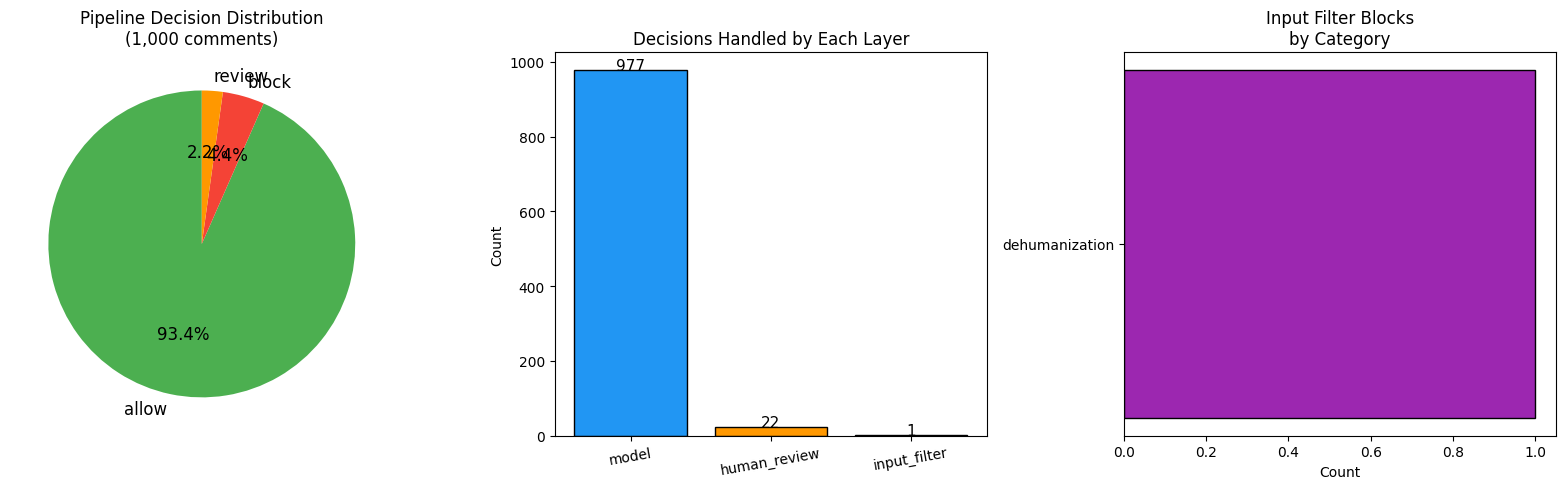

Saved part5_layer_distribution.png


In [29]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Pie chart: decisions
dec_labels = decision_dist.index.tolist()
dec_counts = decision_dist.values.tolist()
colors = {'block': '#F44336', 'allow': '#4CAF50', 'review': '#FF9800'}
pie_colors = [colors.get(l, '#9E9E9E') for l in dec_labels]
axes[0].pie(dec_counts, labels=dec_labels, autopct='%1.1f%%',
            colors=pie_colors, startangle=90, textprops={'fontsize': 12})
axes[0].set_title('Pipeline Decision Distribution\n(1,000 comments)', fontsize=12)

# Bar chart: layer
layer_colors = {
    'input_filter': '#9C27B0', 'model': '#2196F3', 'human_review': '#FF9800'
}
lay_labels = layer_dist.index.tolist()
axes[1].bar(
    lay_labels, layer_dist.values,
    color=[layer_colors.get(l, '#9E9E9E') for l in lay_labels],
    edgecolor='black'
)
axes[1].set_title('Decisions Handled by Each Layer', fontsize=12)
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=10)
for i, v in enumerate(layer_dist.values):
    axes[1].text(i, v+1, str(v), ha='center', fontsize=11)

# Category breakdown for input_filter blocks
cat_df = df_test[df_test['pipeline_layer']=='input_filter']['filter_category'].value_counts()
if len(cat_df) > 0:
    axes[2].barh(cat_df.index.tolist(), cat_df.values, color='#9C27B0', edgecolor='black')
    axes[2].set_title('Input Filter Blocks\nby Category', fontsize=12)
    axes[2].set_xlabel('Count')
else:
    axes[2].text(0.5, 0.5, 'No filter blocks\nin test sample', ha='center', va='center')
    axes[2].set_title('Input Filter Blocks by Category')

plt.tight_layout()
plt.savefig('part5_layer_distribution.png', dpi=150)
plt.show()
print("Saved part5_layer_distribution.png")

## 5.5 Performance on Auto-Actioned Subset (Layer 2 Confident Decisions)

In [30]:
# Auto-actioned: model decisions that are NOT human_review
auto_mask = (df_test['pipeline_layer'] == 'model')  # excludes input_filter (always block)
df_auto = df_test[auto_mask].copy()
print(f"Auto-actioned by model: {len(df_auto)} comments")

# Convert 'block'→1, 'allow'→0 for metric computation
y_true_auto = df_auto['label'].values
y_pred_auto = (df_auto['pipeline_decision'] == 'block').astype(int).values

if len(np.unique(y_true_auto)) > 1:
    f1_auto  = f1_score(y_true_auto, y_pred_auto, average='macro')
    prec_auto = precision_score(y_true_auto, y_pred_auto, zero_division=0)
    rec_auto  = recall_score(y_true_auto, y_pred_auto, zero_division=0)
else:
    f1_auto = prec_auto = rec_auto = float('nan')

print(f"\n{'Metric':<20} {'Value':>8}")
print("-" * 30)
print(f"{'F1 (macro)':<20} {f1_auto:>8.4f}")
print(f"{'Precision':<20} {prec_auto:>8.4f}")
print(f"{'Recall':<20} {rec_auto:>8.4f}")

Auto-actioned by model: 977 comments

Metric                  Value
------------------------------
F1 (macro)             0.7822
Precision              0.7674
Recall                 0.4783


## 5.6 Human Review Queue Analysis

Review queue size: 22 comments

Actual ground-truth breakdown of review queue:
  Toxic comments:      8 (36.4%)
  Non-toxic comments:  14 (63.6%)

  This reveals the true ambiguity in the review queue.
  A queue with ~50% toxic / ~50% non-toxic is genuinely uncertain.
  Human reviewers need to be prepared for both outcomes.


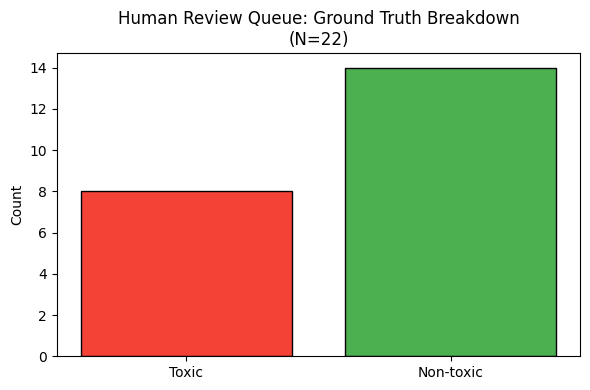

In [31]:
df_review = df_test[df_test['pipeline_decision'] == 'review'].copy()
print(f"Review queue size: {len(df_review)} comments")

if len(df_review) > 0:
    n_toxic_review    = df_review['label'].sum()
    n_nontoxic_review = (df_review['label'] == 0).sum()
    toxic_rate_review = df_review['label'].mean()

    print(f"\nActual ground-truth breakdown of review queue:")
    print(f"  Toxic comments:      {n_toxic_review} ({toxic_rate_review*100:.1f}%)")
    print(f"  Non-toxic comments:  {n_nontoxic_review} ({(1-toxic_rate_review)*100:.1f}%)")
    print(f"\n  This reveals the true ambiguity in the review queue.")
    print(f"  A queue with ~50% toxic / ~50% non-toxic is genuinely uncertain.")
    print(f"  Human reviewers need to be prepared for both outcomes.")

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(['Toxic', 'Non-toxic'], [n_toxic_review, n_nontoxic_review],
           color=['#F44336', '#4CAF50'], edgecolor='black')
    ax.set_title(f'Human Review Queue: Ground Truth Breakdown\n(N={len(df_review)})')
    ax.set_ylabel('Count')
    plt.tight_layout()
    plt.savefig('part5_review_queue.png', dpi=150)
    plt.show()
else:
    print("No comments in review queue with current thresholds.")

## 5.7 Threshold Sensitivity Analysis

In [32]:
# Re-run pipeline decisions with different uncertainty bands
# using the stored confidence scores (no model re-inference needed)

confidence_col = df_test['pipeline_confidence'].values
# Only for model-layer decisions (input_filter decisions always stay blocked)
model_mask = df_test['pipeline_layer'].isin(['model', 'human_review'])

band_configs = [
    ('Narrow (0.45–0.55)', 0.45, 0.55),
    ('Default (0.40–0.60)', 0.40, 0.60),
    ('Wide (0.30–0.70)',    0.30, 0.70),
]

sensitivity_results = []
for label, low, high in band_configs:
    df_m = df_test[model_mask].copy()
    conf = df_m['pipeline_confidence'].values
    y_true_m = df_m['label'].values

    # Classify: block if >= high, allow if <= low, review if in between
    decisions = np.where(conf >= high, 'block', np.where(conf <= low, 'allow', 'review'))
    n_review = (decisions == 'review').sum()
    n_auto   = (decisions != 'review').sum()

    # Auto-action metrics (block/allow only)
    auto_mask_m = decisions != 'review'
    if auto_mask_m.sum() > 0 and len(np.unique(y_true_m[auto_mask_m])) > 1:
        y_pred_auto = (decisions[auto_mask_m] == 'block').astype(int)
        f1_auto_m = f1_score(y_true_m[auto_mask_m], y_pred_auto, average='macro')
    else:
        f1_auto_m = float('nan')

    sensitivity_results.append({
        'Band': label,
        'Low Threshold': low,
        'High Threshold': high,
        'Review Count': n_review,
        'Review %': round(n_review/len(df_m)*100, 1),
        'Auto-action Count': n_auto,
        'Auto F1 (macro)': round(f1_auto_m, 4) if not np.isnan(f1_auto_m) else 'N/A',
    })

df_sens = pd.DataFrame(sensitivity_results)
print("=" * 80)
print("THRESHOLD SENSITIVITY ANALYSIS")
print("=" * 80)
print(df_sens.to_string(index=False))

THRESHOLD SENSITIVITY ANALYSIS
               Band  Low Threshold  High Threshold  Review Count  Review %  Auto-action Count  Auto F1 (macro)
 Narrow (0.45–0.55)           0.45            0.55             0       0.0                999           0.7472
Default (0.40–0.60)           0.40            0.60            22       2.2                977           0.7822
   Wide (0.30–0.70)           0.30            0.70            57       5.7                942           0.7649


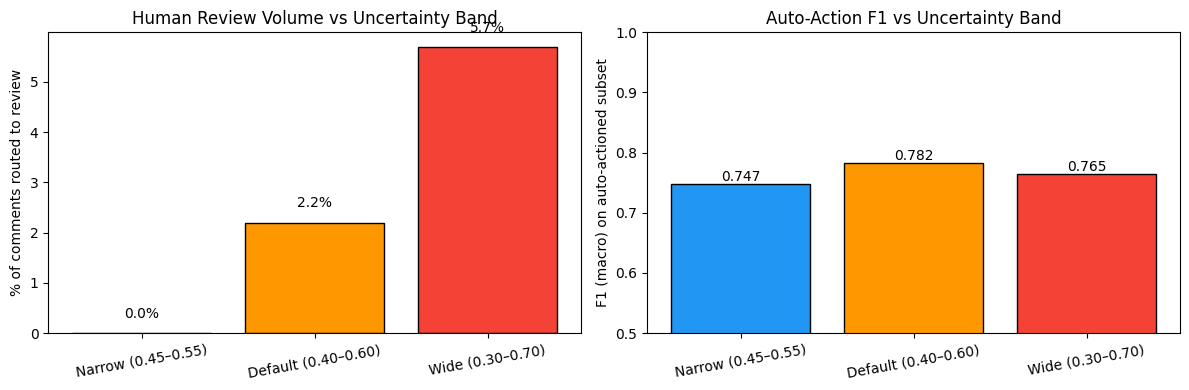

Saved part5_threshold_sensitivity.png


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bands = [r['Band'] for r in sensitivity_results]
review_pcts = [r['Review %'] for r in sensitivity_results]
auto_f1s = [float(r['Auto F1 (macro)']) if r['Auto F1 (macro)'] != 'N/A' else 0 for r in sensitivity_results]

axes[0].bar(bands, review_pcts, color=['#2196F3', '#FF9800', '#F44336'], edgecolor='black')
axes[0].set_title('Human Review Volume vs Uncertainty Band')
axes[0].set_ylabel('% of comments routed to review')
axes[0].tick_params(axis='x', rotation=10)
for i, v in enumerate(review_pcts):
    axes[0].text(i, v+0.3, f'{v}%', ha='center')

axes[1].bar(bands, auto_f1s, color=['#2196F3', '#FF9800', '#F44336'], edgecolor='black')
axes[1].set_title('Auto-Action F1 vs Uncertainty Band')
axes[1].set_ylabel('F1 (macro) on auto-actioned subset')
axes[1].set_ylim(0.5, 1.0)
axes[1].tick_params(axis='x', rotation=10)
for i, v in enumerate(auto_f1s):
    axes[1].text(i, v+0.005, f'{v:.3f}', ha='center')

plt.tight_layout()
plt.savefig('part5_threshold_sensitivity.png', dpi=150)
plt.show()
print("Saved part5_threshold_sensitivity.png")

In [35]:
# Final summary
print("=" * 65)
print("PART 5 FINAL SUMMARY")
print("=" * 65)
print(f"Total comments processed:     {len(df_test)}")
print(f"Layer 1 (input filter) blocks: {(df_test['pipeline_layer']=='input_filter').sum()}")
print(f"Layer 2 (model) decisions:     {(df_test['pipeline_layer']=='model').sum()}")
print(f"Layer 3 (human review):        {(df_test['pipeline_decision']=='review').sum()}")
print()
print(f"Auto-action F1:  {f1_auto:.4f}")
print(f"Auto-action P:   {prec_auto:.4f}")
print(f"Auto-action R:   {rec_auto:.4f}")

PART 5 FINAL SUMMARY
Total comments processed:     1000
Layer 1 (input filter) blocks: 1
Layer 2 (model) decisions:     977
Layer 3 (human review):        22

Auto-action F1:  0.7822
Auto-action P:   0.7674
Auto-action R:   0.4783
